In [1]:
!pip install transformers accelerate einops opencv-python decord torch torchvision torchaudio matplotlib tqdm scikit-learn pandas av evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 91.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 2.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.1 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━

In [2]:
!pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 100.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.4/563.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 57.9 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.33.1
    Uninstalling huggingface-hub-0.33.1:
      Successfully uninstalled huggingface-hub-0.33.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.4
    Uninstalling transformers-4.52.4:
      Successfully uninstalled transformers-4.52.4


In [3]:
import os
import numpy as np
import av
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import (
    Trainer,
    TrainingArguments,
    TimesformerForVideoClassification,
    VideoMAEImageProcessor,
    EarlyStoppingCallback
)
import evaluate
import random

2025-09-19 11:30:13.026203: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758281413.257153      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758281413.316261      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# --- Helper functions from your notebook (no changes needed) ---
def sample_frame_indices(clip_len, frame_sample_rate, seg_len):
    converted_len = int(clip_len * frame_sample_rate)
    end_idx = np.random.randint(converted_len, seg_len)
    start_idx = end_idx - converted_len
    indices = np.linspace(start_idx, end_idx, num=clip_len)
    indices = np.clip(indices, start_idx, end_idx-1).astype(np.int64)
    return indices

def read_video_pyav(container, indices):
    frames = []
    container.seek(0)
    start_index = indices[0]
    end_index = indices[-1]
    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >= start_index and i in indices:
            frames.append(frame.to_image())
    return frames

def get_video_paths_and_labels(root_dir):
    video_paths = []
    labels = []
    label2id = {}
    id2label = {}

    for idx, cls_folder in enumerate(sorted(os.listdir(root_dir))):
        cls_path = os.path.join(root_dir, cls_folder)
        if not os.path.isdir(cls_path):
            continue
        label2id[cls_folder] = idx
        id2label[idx] = cls_folder
        for file in os.listdir(cls_path):
            if file.endswith(".mp4"):
                video_paths.append(os.path.join(cls_path, file))
                labels.append(idx)
    return video_paths, labels, label2id, id2label

# --- Updated VideoDataset to use the processor ---
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, image_processor, num_frames=8):
        self.video_paths = video_paths
        self.labels = labels
        self.image_processor = image_processor
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        container = None
        try:
            container = av.open(video_path)
            # Sample frames
            indices = sample_frame_indices(self.num_frames, 1, container.streams.video[0].frames)
            frames = read_video_pyav(container, indices)
            
            # Process frames with the dedicated processor
            # The processor handles resizing, normalization, and conversion to tensor
            processed_frames = self.image_processor(list(frames), return_tensors="pt")
            
            return {"pixel_values": processed_frames.pixel_values.squeeze(), "labels": torch.tensor(label)}
        finally:
            if container:
                container.close()

In [7]:
# --- Model Initialization ---
def initialise_model(device="cuda", model_name="facebook/timesformer-base-finetuned-k400"):
    label2id = {"NonViolence": 0, "Violence": 1}
    id2label = {0: "NonViolence", 1: "Violence"}

    # Load the processor and model
    processor = VideoMAEImageProcessor.from_pretrained(model_name)
    model = TimesformerForVideoClassification.from_pretrained(
        model_name,
        ignore_mismatched_sizes=True,  # Important for transfer learning
        num_labels=len(label2id),
        label2id=label2id,
        id2label=id2label,
    ).to(device)

    return model, processor

# --- Metrics Calculation ---
metric = evaluate.load("accuracy")

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return metric.compute(predictions=preds, references=p.label_ids)

# --- Revised Training Arguments ---
training_args = TrainingArguments(
    output_dir="/kaggle/temp/timesformer-results",
    eval_strategy="steps",             # Evaluate at regular step intervals
    eval_steps=100,                    # Set evaluation frequency to every 100 steps
    logging_strategy="steps",          # Log metrics at regular step intervals
    logging_steps=50,          
    save_strategy="steps",
    save_total_limit=1,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=2,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=100,
    label_smoothing_factor=0.1,
    optim="adamw_torch",
    lr_scheduler_type="cosine",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    seed=42,
    report_to="none"
)

In [8]:
# --- Data Preparation ---
video_paths, labels, label2id, id2label = get_video_paths_and_labels("/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset")

train_videos, temp_videos, train_labels, temp_labels = train_test_split(
    video_paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_videos, test_videos, val_labels, test_labels = train_test_split(
    temp_videos, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

# --- Initialize Model and Processor ---
model, image_processor = initialise_model()

# --- Create Datasets ---
train_dataset = VideoDataset(train_videos, train_labels, image_processor)
val_dataset = VideoDataset(val_videos, val_labels, image_processor)
test_dataset = VideoDataset(test_videos, test_labels, image_processor)

# --- Initialize Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

# --- Start Training ---
trainer.train()

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/412 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/486M [00:00<?, ?B/s]

Some weights of TimesformerForVideoClassification were not initialized from the model checkpoint at facebook/timesformer-base-finetuned-k400 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/486M [00:00<?, ?B/s]

Step,Training Loss,Validation Loss,Accuracy
100,0.353300,0.338597,0.928328
200,0.281800,0.275380,0.959044
300,0.307700,0.245309,0.986348
400,0.239800,0.308195,0.955631
500,0.284700,0.244841,0.976109
600,0.237400,0.270192,0.955631
700,0.225100,0.256082,0.972696
800,0.218200,0.227015,0.986348


TrainOutput(global_step=800, training_loss=0.2887649703025818, metrics={'train_runtime': 1625.3413, 'train_samples_per_second': 2.519, 'train_steps_per_second': 0.631, 'total_flos': 2.7984145042744934e+18, 'train_loss': 0.2887649703025818, 'epoch': 2.3391812865497075})

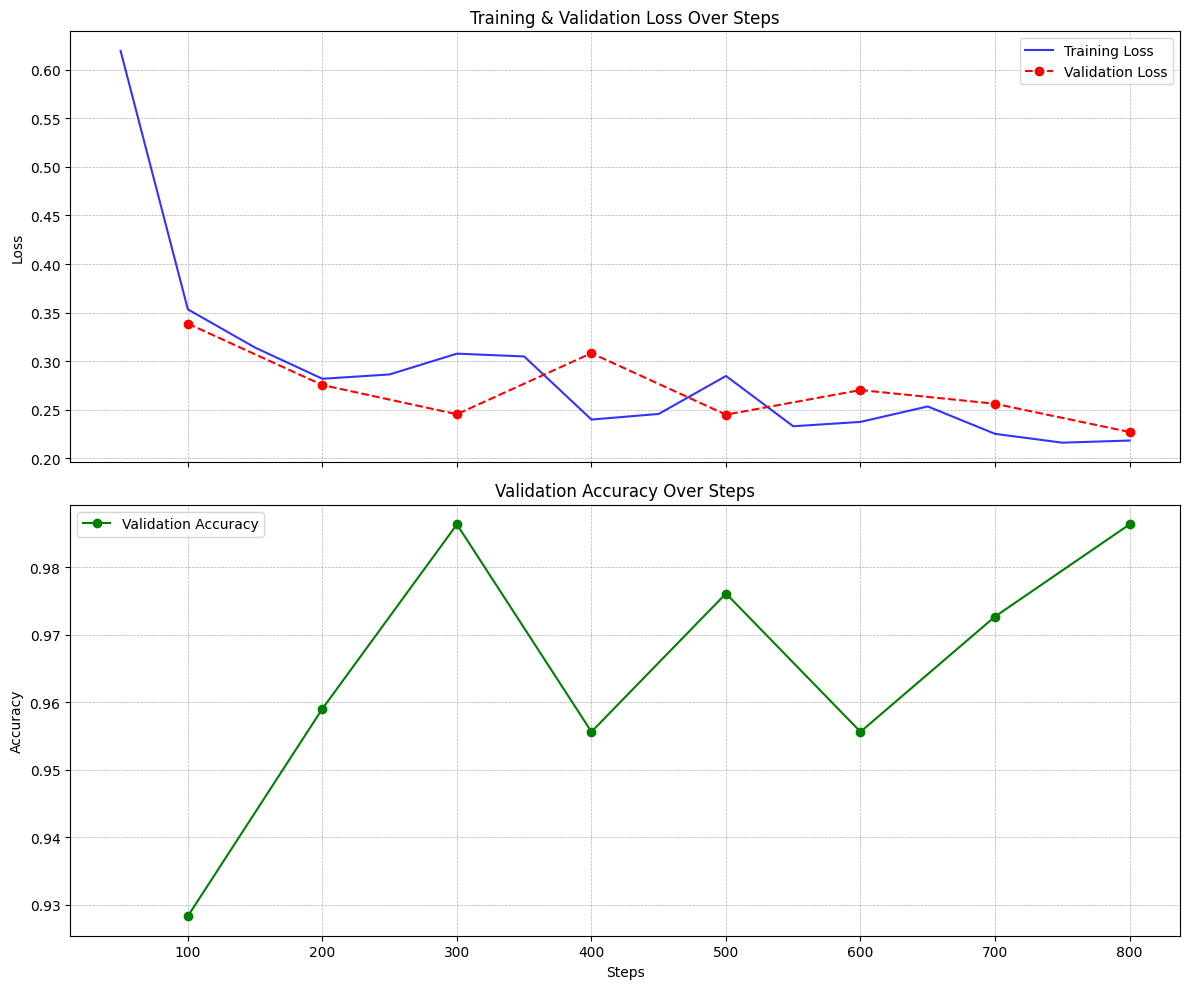

Evaluating on the test set...



Classification Report:

              precision    recall  f1-score   support

 NonViolence       0.99      0.97      0.98       143
    Violence       0.97      0.99      0.98       150

    accuracy                           0.98       293
   macro avg       0.98      0.98      0.98       293
weighted avg       0.98      0.98      0.98       293


Model saved to 'timesformer-violence-detection-model-final'


In [11]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Assume 'trainer' has been trained and logs are populated
# trainer.train() 
logs = trainer.state.log_history

# --- Extract logs for plotting ---
train_loss_steps = [log["step"] for log in logs if "loss" in log]
train_loss = [log["loss"] for log in logs if "loss" in log]

eval_loss_steps = [log["step"] for log in logs if "eval_loss" in log]
eval_loss = [log["eval_loss"] for log in logs if "eval_loss" in log]

eval_acc_steps = [log["step"] for log in logs if "eval_accuracy" in log]
eval_accuracy = [log["eval_accuracy"] for log in logs if "eval_accuracy" in log]


# --- Create Plots ---
# Create a figure with two subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Training and Validation Loss
ax1.plot(train_loss_steps, train_loss, label="Training Loss", color='blue', alpha=0.8)
ax1.plot(eval_loss_steps, eval_loss, label="Validation Loss", color='red', marker='o', linestyle='--')
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss Over Steps")
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend()

# Plot 2: Validation Accuracy
ax2.plot(eval_acc_steps, eval_accuracy, label="Validation Accuracy", color='green', marker='o')
ax2.set_xlabel("Steps")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy Over Steps")
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend()

# Display the plots
plt.tight_layout()
plt.show()

# --- Evaluate on the Test Set ---
print("Evaluating on the test set...")
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# --- Print Classification Report ---
print("\nClassification Report:\n")
target_names = [id2label[i] for i in sorted(id2label)]
print(classification_report(y_true, y_pred, target_names=target_names))

# --- Save the fine-tuned model ---
trainer.save_model("timesformer-violence-detection-model-final")
print("\nModel saved to 'timesformer-violence-detection-model-final'")

In [ ]:
label2id = {"NonViolence": 0, "Violence": 1}
id2label = {0: "NonViolence", 1: "Violence"}

In [23]:
import torch
import av , os
import numpy as np
from transformers import TimesformerForVideoClassification, VideoMAEImageProcessor

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/kaggle/input/timesformer-1/transformers/v1/1/timeSformer-v1"  # Path to your saved model
NUM_FRAMES = 8  # Should match training setup

# --- Load fine-tuned model and processor ---
model_name = 'facebook/timesformer-base-finetuned-k400'
processor = VideoMAEImageProcessor.from_pretrained(model_name)
model = TimesformerForVideoClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# --- Helper functions ---
def sample_frame_indices(num_frames, clip_idx, total_frames):
    """Uniformly sample frame indices from a video."""
    seg_size = float(total_frames - 1) / num_frames
    indices = [int(seg_size * i) for i in range(num_frames)]
    return indices

def read_video_pyav(container, indices):
    """Read specific frames with PyAV and return as numpy arrays."""
    frames = []
    for i, frame in enumerate(container.decode(video=0)):
        if i in indices:
            frames.append(frame.to_ndarray(format="rgb24"))
    return frames

# --- Video Loading and Preprocessing Function ---
def load_and_process_video(video_path):
    container = av.open(video_path)
    total_frames = container.streams.video[0].frames
    indices = sample_frame_indices(NUM_FRAMES, 1, total_frames)
    frames = read_video_pyav(container, indices)
    container.close()
    
    # Process with the same processor used for training
    inputs = processor(list(frames), return_tensors="pt").to(DEVICE)
    # print(inputs["pixel_values"].shape) 
    return inputs


VIDEO_DIR = "/kaggle/input/valdata/val"  # Root folder with videos

results = {}

for root, dirs, files in os.walk(VIDEO_DIR):
    for file in files:
        if file.endswith((".mp4", ".avi", ".mov")):  # Only process video files
            video_path = os.path.join(root, file)
            print(f"Processing {video_path} ...")
            
            video_inputs = load_and_process_video(video_path)
            
            with torch.no_grad():
                outputs = model(**video_inputs)
                pred_class_idx = torch.argmax(outputs.logits, dim=1).item()
            
            predicted_label = model.config.id2label[pred_class_idx]
            results[video_path] = predicted_label
            print(f"Predicted: {predicted_label}")

# --- Final results ---
print("\nAll Predictions:")
for path, label in results.items():
    print(f"{path} -> {label}")


# --- Run Inference on a sample video ---
# sample_video_path = '/kaggle/input/test-video/Horrible street fighting at Dhaka Bangladesh..mp4'   # Replace with your own test video
# print(f"Running inference on: {sample_video_path}")

# video_inputs = load_and_process_video(sample_video_path)

# with torch.no_grad():
#     outputs = model(**video_inputs)
#     logits = outputs.logits
#     pred_class_idx = torch.argmax(logits, dim=1).item()

# predicted_label = model.config.id2label[pred_class_idx]
# print(f"Predicted Label: {predicted_label}")


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Processing /kaggle/input/valdata/val/ApplyLipstick/v_ApplyLipstick_g20_c04.avi ...
Predicted: NonViolence
Processing /kaggle/input/valdata/val/ApplyLipstick/v_ApplyLipstick_g25_c02.avi ...
Predicted: NonViolence
Processing /kaggle/input/valdata/val/ApplyLipstick/v_ApplyLipstick_g10_c04.avi ...
Predicted: NonViolence
Processing /kaggle/input/valdata/val/BasketballDunk/v_BasketballDunk_g05_c03.avi ...
Predicted: Violence
Processing /kaggle/input/valdata/val/BasketballDunk/v_BasketballDunk_g05_c05.avi ...
Predicted: Violence
Processing /kaggle/input/valdata/val/BasketballDunk/v_BasketballDunk_g05_c01.avi ...
Predicted: Violence
Processing /kaggle/input/valdata/val/BaseballPitch/v_BaseballPitch_g12_c01.avi ...
Predicted: Violence
Processing /kaggle/input/valdata/val/BaseballPitch/v_BaseballPitch_g07_c02.avi ...
Predicted: NonViolence
Processing /kaggle/input/valdata/val/BaseballPitch/v_BaseballPitch_g09_c02.avi ...
Predicted: Violence
Processing /kaggle/input/valdata/val/ApplyEyeMakeup/v_A

In [19]:
import torch
import av
import numpy as np
from transformers import TimesformerForVideoClassification, VideoMAEImageProcessor

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/kaggle/working/timesformer-violence-detection-model-final" # Path to your saved model
NUM_FRAMES = 8 # Should match the number of frames used during training

# --- Load fine-tuned model and processor ---
model_name = 'facebook/timesformer-base-finetuned-k400'
processor = VideoMAEImageProcessor.from_pretrained(model_name)
model = TimesformerForVideoClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()


# --- Video Loading and Preprocessing Function for Inference ---
def load_and_process_video(video_path):
    container = av.open(video_path)
    # Extract frames
    indices = sample_frame_indices(NUM_FRAMES, 1, container.streams.video[0].frames)
    frames = read_video_pyav(container, indices)
    container.close()
    
    # Process with the same processor used for training
    inputs = processor(list(frames), return_tensors="pt").to(DEVICE)
    return inputs

# --- Run Inference on a sample video ---
# Replace with the path to your test video
sample_video_path = '/kaggle/input/non-violence-test-video/v_Biking_g01_c02.avi'
print(f"Running inference on: {sample_video_path}")

video_inputs = load_and_process_video(sample_video_path)

with torch.no_grad():
    outputs = model(**video_inputs)
    logits = outputs.logits
    pred_class_idx = torch.argmax(logits, dim=1).item()

predicted_label = model.config.id2label[pred_class_idx]
print(f"Predicted Label: {predicted_label}")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Running inference on: /kaggle/input/non-violence-test-video/v_Biking_g01_c02.avi
Predicted Label: Violence
